# Exploratory Data Analysis

## Содержание

- [Обзор датасета](#Обзор-датасета)
- [Загрузка данных](#Загрузка-данных)
- [SeriousDlqin2yrs](#SeriousDlqin2yrs)
- [RevolvingUtilizationOfUnsecuredLines](#RevolvingUtilizationOfUnsecuredLines)
- [age](#age)
- [DebtRatio](#DebtRatio)
- [MonthlyIncome](#MonthlyIncome)
- [NumberOfDependents](#NumberOfDependents)
- [NumberOfOpenCreditLinesAndLoans](#NumberOfOpenCreditLinesAndLoans)
- [NumberRealEstateLoansOrLines](#NumberRealEstateLoansOrLines)
- [NumberOfTime30-59DaysPastDueNotWorse](#NumberOfTime30-59DaysPastDueNotWorse)
- [NumberOfTime60-89DaysPastDueNotWorse](#NumberOfTime60-89DaysPastDueNotWorse)
- [NumberOfTimes90DaysLate](#NumberOfTimes90DaysLate)
- [Выводы](#Выводы)

## Обзор датасета

Целевая переменная:

- `SeriousDlqin2yrs` (0 или 1) — имел ли заемщик серьезную просрочку (90 дней или более) в течение последних 2 лет.

Признаки:

- `age` (целое число) — возраст заемщика в годах.

- `MonthlyIncome` (вещественное число) — ежемесячный доход заемщика.

- `NumberOfDependents` (целое число) — количество иждивенцев в семье, не включая самого заемщика (супруг, дети и др.).

- `RevolvingUtilizationOfUnsecuredLines` (процент) — коэффициент использования необеспеченных кредитных линий. Рассчитывается как общий баланс по кредитным картам и персональным кредитным линиям (за исключением недвижимости и рассрочек, таких как автокредиты), деленный на сумму кредитных лимитов.

- `DebtRatio` (процент) — отношение долговой нагрузки к доходу. Включает ежемесячные платежи по долгам, алименты и расходы на жизнь, деленные на ежемесячный доход.

- `NumberOfOpenCreditLinesAndLoans` (целое число) — общее количество открытых кредитов (например, автокредиты или ипотека) и кредитных линий (например, кредитные карты).

- `NumberRealEstateLoansOrLines` (целое число) — количество ипотечных кредитов и кредитов под залог недвижимости, включая кредитные линии под залог собственного капитала.

- `NumberOfTime3059DaysPastDueNotWorse` (целое число) — количество случаев, когда заемщик имел просрочку от 30 до 59 дней (но не хуже) за последние 2 года.

- `NumberOfTime60-89DaysPastDueNotWorse` (целое число) — количество случаев, когда заемщик имел просрочку от 60 до 89 дней (но не хуже) за последние 2 года.

- `NumberOfTimes90DaysLate` (целое число) — количество случаев, когда заемщик имел просрочку 90 дней или более.

## Загрузка данных

In [132]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

seed = 42
np.random.seed(seed)

In [4]:
train = pd.read_csv('../data/raw/GiveMeSomeCredit/cs-training.csv', index_col='Unnamed: 0')

X_train = train.drop(columns=['SeriousDlqin2yrs'])
y_train = train['SeriousDlqin2yrs']

## SeriousDlqin2yrs

In [590]:
train.SeriousDlqin2yrs.describe()

count    150000.000000
mean          0.066840
std           0.249746
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SeriousDlqin2yrs, dtype: float64

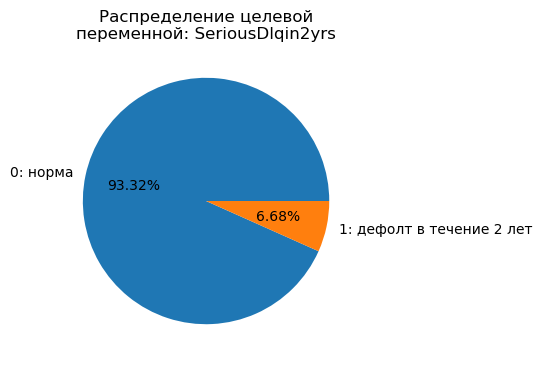

In [583]:
counts = train['SeriousDlqin2yrs'].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(counts, autopct='%.2f%%', labels=['0: норма', '1: дефолт в течение 2 лет'])
plt.title('Распределение целевой\nпеременной: SeriousDlqin2yrs')
plt.show()

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

Имеем неполный набор `MonthlyIncome` и `NumberOfDependents`

In [7]:
print(f"Пропусков в MonthlyIncome:      {train.MonthlyIncome.isna().mean() * 100:.2f}%")
print(f"Пропусков в NumberOfDependents: {train.NumberOfDependents.isna().mean() * 100:.2f}%")

Пропусков в MonthlyIncome:      19.82%
Пропусков в NumberOfDependents: 2.62%


In [8]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## RevolvingUtilizationOfUnsecuredLines

In [593]:
train.RevolvingUtilizationOfUnsecuredLines.describe(percentiles=[.25, .5, .75, .95, .99, .997])

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
95%           1.000000
99%           1.092956
99.7%         1.760802
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [10]:
RUUL_bins = np.concatenate((np.linspace(0, 1, 11),
                            [1.5, 2, 100],
                            np.arange(1000, train['RevolvingUtilizationOfUnsecuredLines'].max()+1, 1000),
                            [train['RevolvingUtilizationOfUnsecuredLines'].max()]))

train['RUUL_bin'] = pd.cut(train['RevolvingUtilizationOfUnsecuredLines'],
                           bins=RUUL_bins,
                           duplicates='drop',
                           include_lowest=True)

RUUL_stats = train.groupby('RUUL_bin').agg(DefaultRisk=('SeriousDlqin2yrs', 'mean'))

RUUL_stats['NumberOfClients'] = train['RUUL_bin'].value_counts()
RUUL_stats

,DefaultRisk,NumberOfClients
RUUL_bin,,
"(-0.001, 0.1]",0.018104,64404
"(0.1, 0.2]",0.027795,17305
"(0.2, 0.3]",0.037054,11173
"(0.3, 0.4]",0.052704,8671
"(0.4, 0.5]",0.065512,7159
...,...,...
"(46000.0, 47000.0]",NaN,0
"(47000.0, 48000.0]",NaN,0
"(48000.0, 49000.0]",NaN,0


## age

In [594]:
train.age.describe()

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

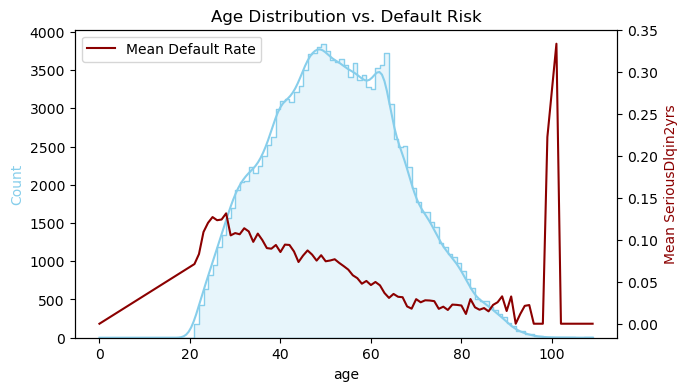

In [305]:
fig, ax1 = plt.subplots(figsize=(7, 4))

sns.histplot(data=train, x='age', alpha=0.2, element='step', kde=True, ax=ax1, color='skyblue', bins=sorted(train.age.unique()))
ax1.set_ylabel('Count', color='skyblue')

ax2 = ax1.twinx()

age_risk = train.groupby('age')['SeriousDlqin2yrs'].mean()

sns.lineplot(data=age_risk, ax=ax2, color='darkred', label='Mean Default Rate')
ax2.set_ylabel('Mean SeriousDlqin2yrs', color='darkred')

plt.title('Age Distribution vs. Default Risk')
plt.show()

Пик риска при возрасте около 100 лет, обусловлен малой численностью респондентов и случайным всплеском в данных.

In [12]:
age_stats = train.groupby('age').agg(count=('age', 'size'), DefaultRisk=('SeriousDlqin2yrs', 'mean')).reset_index()

age_stats.loc[age_stats.age >= 90]

,age,count,DefaultRisk
70,90,198,0.015152
71,91,154,0.032468
72,92,93,0.000000
73,93,87,0.011494
74,94,47,0.021277
75,95,45,0.022222
76,96,18,0.000000
77,97,17,0.000000
78,98,6,0.000000
79,99,9,0.222222


In [13]:
train.groupby('age').agg(DefaultRisk=('SeriousDlqin2yrs', 'mean'))

,DefaultRisk
age,
0,0.000000
21,0.071038
22,0.082949
23,0.109204
24,0.120098
...,...
102,0.000000
103,0.000000
105,0.000000


## DebtRatio

In [595]:
train.DebtRatio.describe()

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

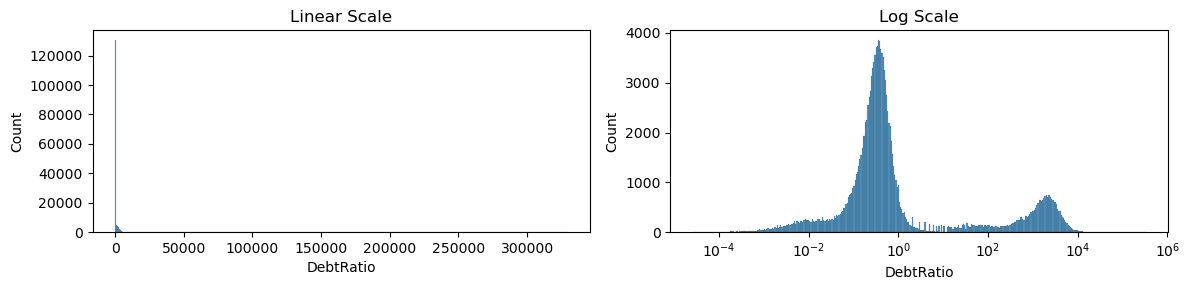

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

sns.histplot(data=train, x='DebtRatio', bins=500, ax=axs[0]);
sns.histplot(data=train, x='DebtRatio', log_scale=True, ax=axs[1]);

axs[1].set_title('Log Scale')
axs[0].set_title('Linear Scale')

plt.tight_layout()
plt.show()

In [15]:
train['DebtRatio_q_bin'] = pd.qcut(train.DebtRatio, q=20, duplicates='drop')
train.groupby('DebtRatio_q_bin').agg(Count=('DebtRatio', 'size'),
                                     MonthlyIncome_mean=('MonthlyIncome', 'mean'),
                                     DefaultRisk=('SeriousDlqin2yrs', 'mean'))

,Count,MonthlyIncome_mean,DefaultRisk
DebtRatio_q_bin,,,
"(-0.001, 0.00433]",7501,7612.988774,0.058126
"(0.00433, 0.0309]",7499,7258.774637,0.049473
"(0.0309, 0.0864]",7500,7432.922400,0.070800
"(0.0864, 0.134]",7500,7412.272933,0.065600
"(0.134, 0.175]",7500,7263.369467,0.060133
"(0.175, 0.214]",7500,7664.277467,0.060533
"(0.214, 0.251]",7500,7601.900267,0.053333
"(0.251, 0.287]",7500,7642.118400,0.054800
"(0.287, 0.325]",7500,7431.823600,0.052667


За пиком риска на интервале (0.868, 4.0] следует падение заработной платы почти до нуля

In [16]:
train['DebtRatio_bin'] = pd.cut(train.DebtRatio, duplicates='drop', bins=np.arange(0, 329665, 2), include_lowest=True)
train['DebtRatio_bin_left'] = train.DebtRatio_bin.map(lambda x: x.left)
train['MonthlyIncome_mean_DR_bin'] = train.groupby('DebtRatio_bin_left').MonthlyIncome.transform('mean')

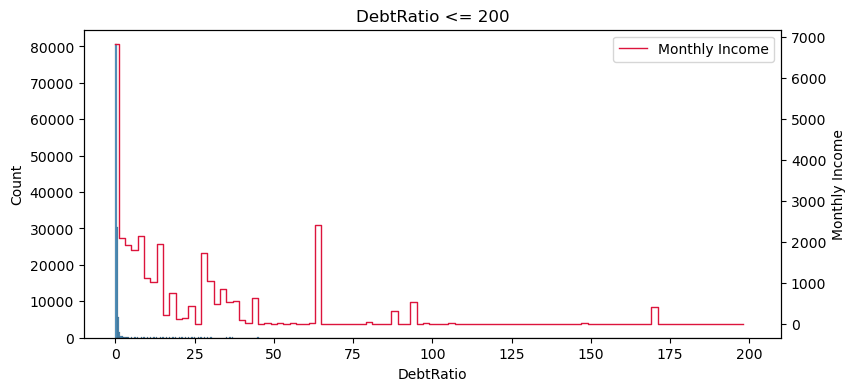

In [17]:
fig, ax1 = plt.subplots(figsize=(9, 4))

sns.histplot(data=train.loc[train.DebtRatio.le(200)], x='DebtRatio', bins=500, ax=ax1, label='Count')

ax2 = ax1.twinx()

sns.lineplot(
    data=train.loc[train.DebtRatio.le(200)], 
    x='DebtRatio_bin_left', 
    y='MonthlyIncome_mean_DR_bin', 
    errorbar=None,
    drawstyle='steps-mid',
    color='crimson',
    linewidth=1,
    ax=ax2,
    label='Monthly Income'
)

ax1.grid(False)
ax2.set_title('DebtRatio <= 200');
ax2.set_ylabel('Monthly Income');

In [18]:
train.loc[train.DebtRatio.between(50, 75) & train.MonthlyIncome.ge(100)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RUUL_bin,DebtRatio_q_bin,DebtRatio_bin,DebtRatio_bin_left,MonthlyIncome_mean_DR_bin
55487,0,0.228582,65,0,65.712209,7223.0,14,0,0,0,0.0,"(0.2, 0.3]","(4.0, 269.15]","(64.0, 66.0]",64.0,2407.666667
61020,0,0.068091,72,0,62.138614,100.0,17,0,2,0,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(62.0, 64.0]",62.0,16.142857


Пик около `DebtRatio ≈ 65` обусловлен наличием респондента с высокой (7223) зарплатой 

In [19]:
train['DebtRatio_bin'] = pd.cut(train.DebtRatio,
                                bins=np.concatenate([[0, 0.5, 1, 2, 3.5, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
                                                    np.arange(100, 4001, 100),
                                                    [train.DebtRatio.max()]]),
                                duplicates='drop')

train.groupby('DebtRatio_bin').agg(Count=('DebtRatio', 'size'),
                                     MonthlyIncome_mean=('MonthlyIncome', 'mean'),
                                     DefaultRisk=('SeriousDlqin2yrs', 'mean'))


,Count,MonthlyIncome_mean,DefaultRisk
DebtRatio_bin,,,
"(0.0, 0.5]",89595,7385.688922,0.059323
"(0.5, 1.0]",21155,5445.323819,0.098322
"(1.0, 2.0]",4092,3470.462106,0.131720
"(2.0, 3.5]",883,2121.987637,0.087203
"(3.5, 5.0]",516,2027.171946,0.063953
"(5.0, 10.0]",769,1832.902439,0.042913
"(10.0, 15.0]",577,1258.951807,0.034662
"(15.0, 20.0]",438,865.333333,0.043379
"(20.0, 25.0]",415,263.828571,0.067470


In [20]:
train.loc[train.DebtRatio.gt(50) & (train.MonthlyIncome.gt(1)), ['MonthlyIncome', 'DebtRatio']]

,MonthlyIncome,DebtRatio
984,21.0,106.272727
1616,2.0,364.000000
5856,25.0,149.423077
10405,56.0,57.000000
14810,10.0,206.727273
17831,2.0,107.333333
37907,55.0,52.017857
40083,4.0,93.000000
43785,2.0,450.333333
55065,9.0,141.400000


In [328]:
threshold = 50

DR_pct_gt_60   = 100 * (1 - train.DebtRatio.rank(pct=True).loc[train.DebtRatio == threshold].iloc[0])
DR_MonInc_le_1 = 100 * (train.loc[train.DebtRatio.gt(threshold) & (train.MonthlyIncome.le(0) | train.MonthlyIncome.isna()), 'MonthlyIncome'].isna().shape[0] / train.shape[0])

print(f"Процент клиентов с DebtRatio > {threshold}: {DR_pct_gt_60:.2f}%")
print(f"Из них с доходом == 0 или NaN: {100 * DR_MonInc_le_1 / DR_pct_gt_60:.2f}%")

Процент клиентов с DebtRatio > 50: 17.30%
Из них с доходом == 0 или NaN: 97.96%


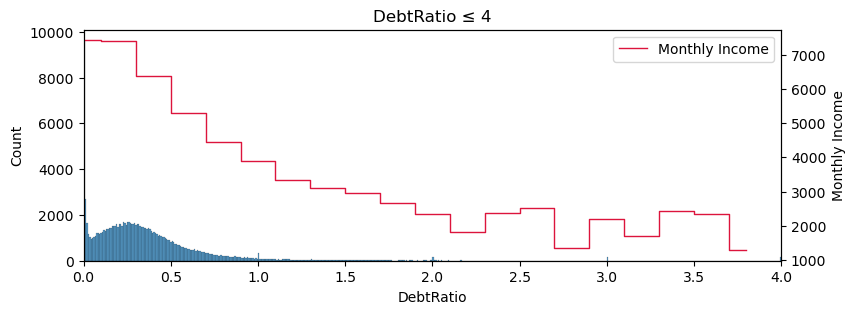

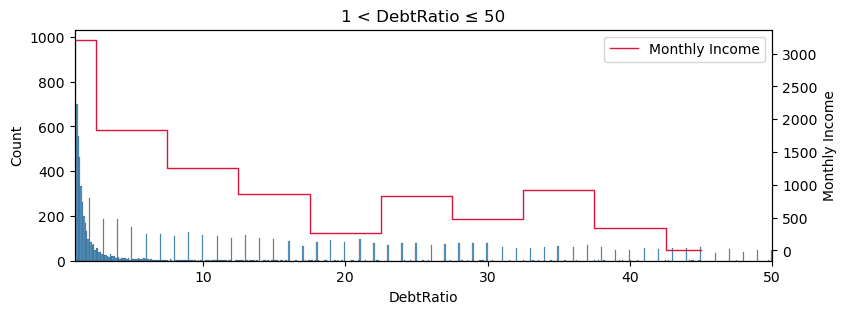

In [326]:
def plot_debt_ratio_vs_income(
    df: pd.DataFrame,
    *,
    mask: pd.Series,
    bin_step: float,
    title: str,
    hist_bins: int = 500,
    xlim: tuple[float, float] | None = None,
    figsize: tuple[int, int] = (9, 3),
):
    d = df.loc[mask, ["DebtRatio", "MonthlyIncome"]].copy()

    max_edge = df["DebtRatio"].max()
    edges = np.r_[np.arange(0, 100, bin_step), max_edge]

    bins = pd.cut(d["DebtRatio"], bins=edges, include_lowest=True, duplicates="drop")

    mean_income = (
        d.groupby(bins, observed=True)["MonthlyIncome"]
        .mean()
        .rename("MonthlyIncome_mean")
        .reset_index()
    )

    mean_income["DebtRatio_bin_left"] = mean_income[bins.name].apply(lambda iv: iv.left)

    fig, ax1 = plt.subplots(figsize=figsize)

    sns.histplot(
        data=d,
        x="DebtRatio",
        bins=hist_bins,
        ax=ax1,
        label="Count",
    )

    ax2 = ax1.twinx()
    sns.lineplot(
        data=mean_income,
        x="DebtRatio_bin_left",
        y="MonthlyIncome_mean",
        errorbar=None,
        drawstyle="steps-mid",
        color="crimson",
        linewidth=1,
        ax=ax2,
        label="Monthly Income",
    )

    if xlim is not None:
        ax1.set_xlim(*xlim)

    ax1.grid(False)
    ax2.set_title(title)
    ax2.set_ylabel("Monthly Income")
    plt.show()


plot_debt_ratio_vs_income(
    train,
    mask=train["DebtRatio"].le(4),
    bin_step=0.2,
    title="DebtRatio ≤ 4",
    xlim=(0, 4),
)

plot_debt_ratio_vs_income(
    train,
    mask=train["DebtRatio"].gt(1) & train["DebtRatio"].le(50),
    bin_step=5,
    title="1 < DebtRatio ≤ 50",
    xlim=(1, 50),
)

In [329]:
median_income = 10000#train.MonthlyIncome.median()
print(f"Медианная зарплата: {median_income:.2f}")

print()

rich_pct_1_25 = train.loc[train.DebtRatio.between(1, 25) & train.MonthlyIncome.gt(median_income), 'DebtRatio'].count() / train.loc[train.DebtRatio.between(1, 25), 'DebtRatio'].count()
print(f"Зп больше медианы на DebtRatio (1, 25]: {100 * rich_pct_1_25:.2f}%")
nowork_pct_1_25 = train.loc[train.DebtRatio.between(1, 25) & (train.MonthlyIncome.eq(0) | train.MonthlyIncome.isna()), 'DebtRatio'].shape[0] / train.loc[train.DebtRatio.between(1, 25), 'DebtRatio'].count()
print(f"Зп == 0 или NaN на DebtRatio (1, 25]: {100 * nowork_pct_1_25:.2f}%")

print()

rich_pct_25_50 = train.loc[train.DebtRatio.between(25, 50) & train.MonthlyIncome.gt(median_income), 'DebtRatio'].count() / train.loc[train.DebtRatio.between(25, 50), 'DebtRatio'].count()
print(f"Зп больше медианы на DebtRatio (25, 50]: {100 * rich_pct_25_50:.2f}%")
nowork_pct_25_50 = train.loc[train.DebtRatio.between(25, 50) & (train.MonthlyIncome.eq(0) | train.MonthlyIncome.isna()), 'DebtRatio'].shape[0] / train.loc[train.DebtRatio.between(25, 50), 'DebtRatio'].count()
print(f"Зп == 0 или NaN на DebtRatio (25, 50]: {100 * nowork_pct_25_50:.2f}%")

train.loc[train.DebtRatio.between(20, 40) & train.MonthlyIncome.ge(2000)]

Медианная зарплата: 10000.00

Зп больше медианы на DebtRatio (1, 25]: 1.64%
Зп == 0 или NaN на DebtRatio (1, 25]: 34.75%

Зп больше медианы на DebtRatio (25, 50]: 0.19%
Зп == 0 или NaN на DebtRatio (25, 50]: 96.86%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RUUL_bin,DebtRatio_q_bin,DebtRatio_bin,DebtRatio_bin_left,MonthlyIncome_mean_DR_bin
34110,0,0.000000,63,5,30.326467,8300.0,16,1,2,1,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(30.0, 35.0]",30.0,1037.625000
50217,0,0.340559,63,0,28.171455,15000.0,14,0,4,0,1.0,"(0.3, 0.4]","(4.0, 269.15]","(25.0, 30.0]",28.0,1732.722222
59910,1,0.698978,48,0,35.440782,13500.0,11,0,0,0,1.0,"(0.6, 0.7]","(4.0, 269.15]","(35.0, 40.0]",34.0,843.875000
60048,1,0.000000,57,0,24.189647,6200.0,6,0,0,0,1.0,"(-0.001, 0.1]","(4.0, 269.15]","(20.0, 25.0]",24.0,429.400000
77259,1,0.815674,50,2,29.612885,3600.0,16,0,0,0,0.0,"(0.8, 0.9]","(4.0, 269.15]","(25.0, 30.0]",28.0,1732.722222
80264,0,0.161309,31,1,33.610994,6166.0,14,0,2,0,2.0,"(0.1, 0.2]","(4.0, 269.15]","(30.0, 35.0]",32.0,482.307692
91948,0,0.161541,68,0,37.823700,2750.0,8,0,4,0,0.0,"(0.1, 0.2]","(4.0, 269.15]","(35.0, 40.0]",36.0,519.000000
96900,0,0.004480,74,0,38.201133,6000.0,6,0,0,0,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(35.0, 40.0]",38.0,555.272727
139095,0,0.514390,44,2,28.632287,12487.0,9,0,1,1,3.0,"(0.5, 0.6]","(4.0, 269.15]","(25.0, 30.0]",28.0,1732.722222


Доход <= 1 у 99.82% клиентов с `DebtRatio > 50` и у всех клиентов с `DebtRatio >= 451`

In [24]:
DR_50_pct  = train['DebtRatio'].rank(pct=True).loc[train.DebtRatio.eq(50)].iloc[0]
DR_451_pct = train['DebtRatio'].rank(pct=True).loc[train.DebtRatio.eq(451)].iloc[0]
print(f"Всего {100 * (1 - DR_50_pct):.2f}% пользователей с DebtRatio > 50")
print(f"Всего {100 * (1 - DR_451_pct):.2f}% пользователей с DebtRatio > 451")

Всего 17.30% пользователей с DebtRatio > 50
Всего 14.01% пользователей с DebtRatio > 451


## MonthlyIncome

In [597]:
train.MonthlyIncome.describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [25]:
missing_income = train.MonthlyIncome.isna().sum()
print(f"Количество пропусков: {missing_income} ({100 * missing_income / train.shape[0]:.2f}%)\n")

Количество пропусков: 29731 (19.82%)

Пропусков при DebtRatio > 50:  24138 (81.19%)
Пропусков при DebtRatio > 451: 19674 (66.17%)


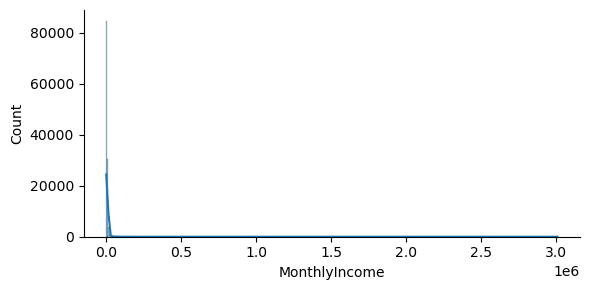

In [596]:
sns.displot(data=train, x='MonthlyIncome', bins=400, kde=True, height=3, aspect=2);

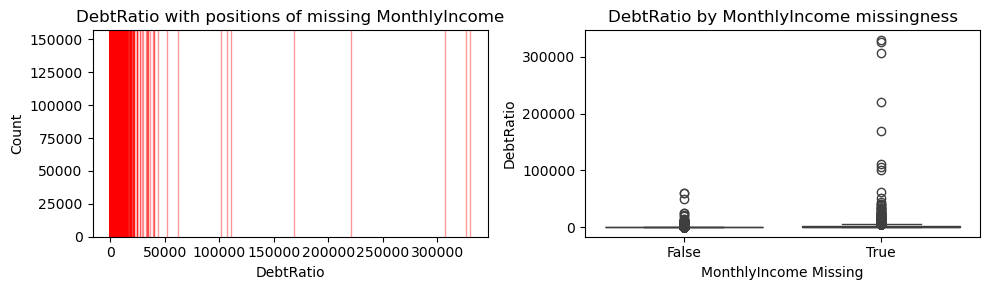

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

df = train[train.DebtRatio.notna()]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.histplot(df.DebtRatio, bins=50, kde=False, color='lightblue', ax=axes[0])

missing_DR = df.loc[df.MonthlyIncome.isna(), 'DebtRatio']
for x in missing_DR:
    axes[0].axvline(x=x, color='red', alpha=0.4, linewidth=1)
axes[0].set_xlabel('DebtRatio')
axes[0].set_ylabel('Count')
axes[0].set_title('DebtRatio with positions of missing MonthlyIncome')

df_plot = df.copy()
df_plot['Income_Missing'] = df_plot.MonthlyIncome.isna()

sns.boxplot(data=df_plot, y='DebtRatio', x='Income_Missing', ax=axes[1])
axes[1].set_xlabel('MonthlyIncome Missing')
axes[1].set_ylabel('DebtRatio')
axes[1].set_title('DebtRatio by MonthlyIncome missingness')

plt.tight_layout()
plt.show()

In [40]:
DR_max_income_notna = train.loc[train.MonthlyIncome.notna(), 'DebtRatio'].max()
print(f"Максимальный DebtRatio с MonthlyIncome notna: {DR_max_income_notna}")

Максимальный DebtRatio с MonthlyIncome notna: 61106.5


In [99]:
print(f"Клиенты с DebtRatio > {DR_max_income_notna}:")
train.loc[train.DebtRatio.gt(DR_max_income_notna), 'SeriousDlqin2yrs']

Клиенты с DebtRatio > 61106.5:


4855      0
7514      0
36601     0
58901     0
60153     0
66786     0
69846     0
103042    0
127048    0
Name: SeriousDlqin2yrs, dtype: int64

Мода DebtRatio с MonthlyIncome.notna(): 0.34
Мода DebtRatio с MonthlyIncome.isna():  1995.73
Мода DebtRatio с MonthlyIncome == 0:    1500.28


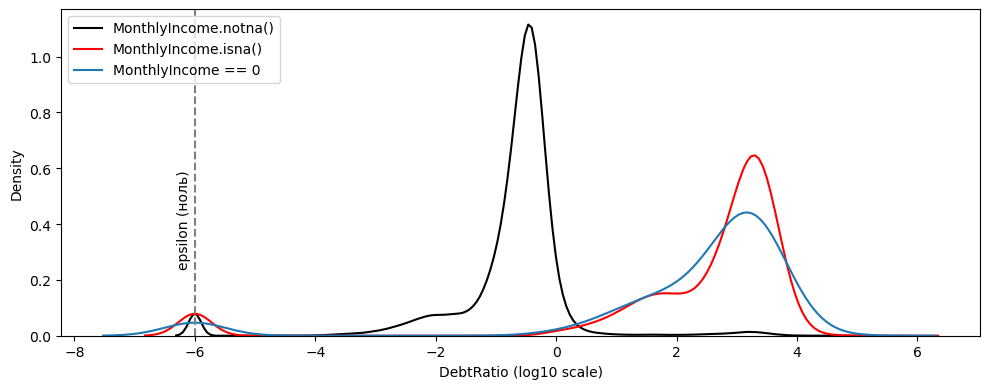

In [247]:
x_notna = train.loc[train.MonthlyIncome.notna(), 'DebtRatio']
x_isna  = train.loc[train.MonthlyIncome.isna(),  'DebtRatio']
x_zero  = train.loc[train.MonthlyIncome.eq(0),   'DebtRatio']

def get_mode(ax, idx):
    xs = ax.get_lines()[idx].get_xdata()
    ys = ax.get_lines()[idx].get_ydata()
    return xs[np.argmax(ys)]

fig, ax = plt.subplots(figsize=(10, 4))

epsilon = 1e-6
sns.kdeplot(x=np.log10(x_notna + epsilon), ax=ax, color='black', label='MonthlyIncome.notna()')
sns.kdeplot(x=np.log10(x_isna  + epsilon), ax=ax, color='red',   label='MonthlyIncome.isna()')
sns.kdeplot(x=np.log10(x_zero  + epsilon), ax=ax,                label='MonthlyIncome == 0')

plt.axvline(x=np.log10(epsilon), color='gray', linestyle='--')
plt.text(np.log10(epsilon)-0.3, 0.25, 'epsilon (ноль)', rotation=90)

print(f"Мода DebtRatio с MonthlyIncome.notna(): {10 ** get_mode(ax, 0):.2f}")
print(f"Мода DebtRatio с MonthlyIncome.isna():  {10 ** get_mode(ax, 1):.2f}")
print(f"Мода DebtRatio с MonthlyIncome == 0:    {10 ** get_mode(ax, 2):.2f}")

ax.legend(loc='upper left')
ax.set_xlabel('DebtRatio (log10 scale)')
plt.tight_layout()
plt.show()

In [119]:
missing_income_DR_gt_1   = train.loc[train.DebtRatio.gt(1)   & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_10  = train.loc[train.DebtRatio.gt(10)  & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_50  = train.loc[train.DebtRatio.gt(50)  & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_451 = train.loc[train.DebtRatio.gt(451) & train.MonthlyIncome.isna(), 'DebtRatio'].count()

print(f"Пропусков при DebtRatio > 1:   {missing_income_DR_gt_1} ({100 * missing_income_DR_gt_1 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 10:  {missing_income_DR_gt_10} ({100 * missing_income_DR_gt_10 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 50:  {missing_income_DR_gt_50} ({100 * missing_income_DR_gt_50 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 451: {missing_income_DR_gt_451} ({100 * missing_income_DR_gt_451 / missing_income:.2f}%)")

Пропусков при DebtRatio > 1:   27904 (93.85%)
Пропусков при DebtRatio > 10:  26771 (90.04%)
Пропусков при DebtRatio > 50:  24138 (81.19%)
Пропусков при DebtRatio > 451: 19674 (66.17%)


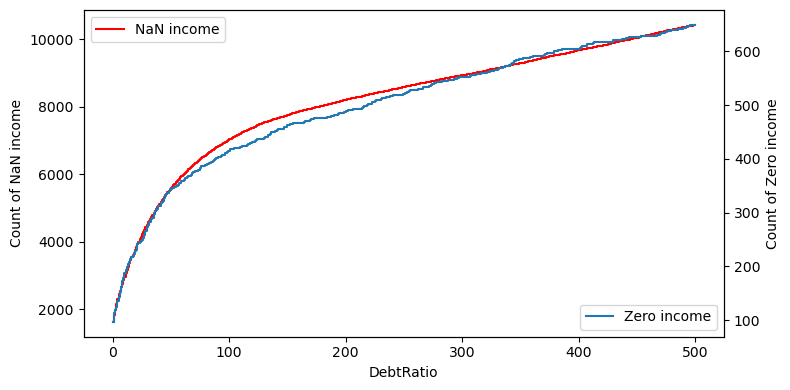

In [296]:
missing_income = train.loc[train.MonthlyIncome.isna() & train.DebtRatio.between(0, 500), 'DebtRatio']
zero_income = train.loc[train.MonthlyIncome.eq(0) & train.DebtRatio.between(0, 500), 'DebtRatio']

fig, ax1 = plt.subplots(figsize=(8, 4))

sns.histplot(missing_income, bins=500, cumulative=1, element="step", color='red', fill=False, ax=ax1, label='NaN income')
plt.ylabel('Count of NaN income')
ax1.legend()

ax2=ax1.twinx()

sns.histplot(zero_income, bins=500, cumulative=1, element="step", fill=False, ax=ax2, label='Zero income')
plt.ylabel('Count of Zero income')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

## NumberOfDependents

In [434]:
missing_count = train.NumberOfDependents.isna().sum()
missing_pct   = train.NumberOfDependents.isna().mean() * 100

print(f"Количество пропусков: {missing_count:.2f} ({missing_pct:.2f}%)")
train.NumberOfDependents.describe()

Количество пропусков: 3924.00 (2.62%)


count    146076.000000
mean          0.757222
std           1.115086
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: NumberOfDependents, dtype: float64

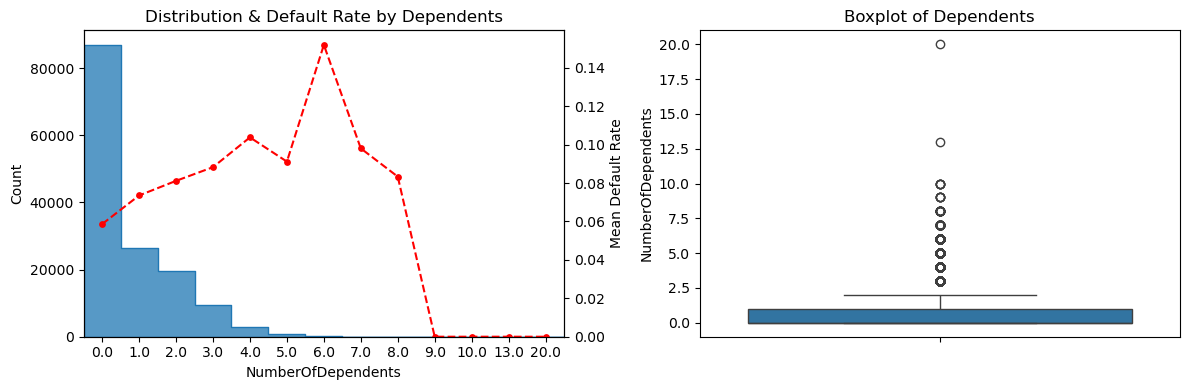

In [392]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=train, x='NumberOfDependents', discrete=True, element='step', ax=axs[0])
twin_ax0 = axs[0].twinx()
sns.pointplot(
    data=train,
    x='NumberOfDependents',
    y='SeriousDlqin2yrs',
    errorbar=None,
    color='red',
    markers='o',
    linewidth=1.5,
    linestyles='--',
    ax=twin_ax0
)

axs[0].set_title('Distribution & Default Rate by Dependents')

twin_ax0.set_ylabel('Mean Default Rate')
twin_ax0.set_ylim(0, None)

sns.boxplot(data=train, y='NumberOfDependents', ax=axs[1])
axs[1].set_title('Boxplot of Dependents')

plt.tight_layout()
plt.show()


In [533]:
(train.groupby('NumberOfDependents')
    .agg(
        Count=('NumberOfDependents', 'size'),
        DefaultRate=('SeriousDlqin2yrs', 'mean')
    )
    .assign(
        Percent=lambda x: (x['Count'] / x['Count'].sum()) * 100,
        CumPercent=lambda x: x['Percent'].cumsum(),
        RevCumPercent=lambda x: x['Percent'].iloc[::-1].cumsum().iloc[::-1]
    )
)

,Count,DefaultRate,Percent,CumPercent,RevCumPercent
NumberOfDependents,,,,,
0.0,86902,0.058629,59.490950,59.490950,100.000000
1.0,26316,0.073529,18.015280,77.506230,40.509050
2.0,19522,0.081139,13.364276,90.870506,22.493770
3.0,9483,0.088263,6.491826,97.362332,9.129494
4.0,2862,0.103774,1.959254,99.321586,2.637668
5.0,746,0.091153,0.510693,99.832279,0.678414
6.0,158,0.151899,0.108163,99.940442,0.167721
7.0,51,0.098039,0.034913,99.975355,0.059558
8.0,24,0.083333,0.016430,99.991785,0.024645


## NumberOfOpenCreditLinesAndLoans

In [481]:
train.NumberOfOpenCreditLinesAndLoans.describe()

count    150000.000000
mean          8.452760
std           5.145951
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          58.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

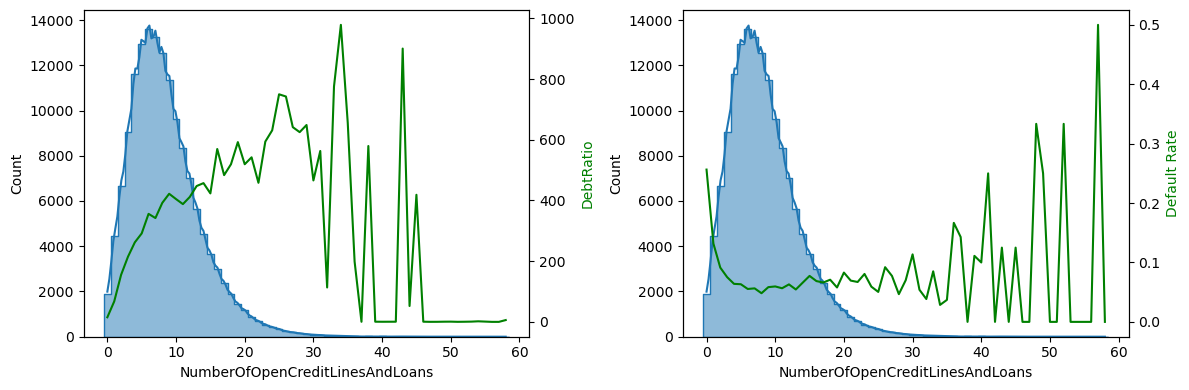

In [658]:
default_rate = train.groupby('NumberOfOpenCreditLinesAndLoans').SeriousDlqin2yrs.mean()
debt_ratio   = train.groupby('NumberOfOpenCreditLinesAndLoans').DebtRatio.mean()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=train, x='NumberOfOpenCreditLinesAndLoans', element='step', discrete=True, kde=True, ax=axs[0]);
ax2 = axs[0].twinx()
sns.lineplot(data=debt_ratio, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')

sns.histplot(data=train, x='NumberOfOpenCreditLinesAndLoans', element='step', discrete=True, kde=True, ax=axs[1]);
ax2 = axs[1].twinx()
sns.lineplot(data=default_rate, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')
ax2.set_ylabel('Default Rate')

plt.tight_layout()

In [659]:
counts = train.groupby('NumberOfOpenCreditLinesAndLoans').size()

stats = pd.concat([counts, default_rate, debt_ratio], axis=1)
stats.columns = ['Count', 'DefaultRate', 'AvgDebtRatio']
stats

,Count,DefaultRate,AvgDebtRatio
NumberOfOpenCreditLinesAndLoans,,,
0,1888,0.256356,15.161704
1,4438,0.131816,67.434211
2,6666,0.091359,155.001760
3,9058,0.075293,214.554490
4,11609,0.064002,262.078596
5,12931,0.063336,291.429694
6,13614,0.055384,355.996270
7,13245,0.056399,342.164066
8,12562,0.048241,392.206381


In [660]:
100 * train.NumberOfOpenCreditLinesAndLoans.le(26).mean()

99.4

In [663]:
stats.reset_index().iloc[:26].corr()

,NumberOfOpenCreditLinesAndLoans,Count,DefaultRate,AvgDebtRatio
NumberOfOpenCreditLinesAndLoans,1.000000,-0.701014,-0.404872,0.926523
Count,-0.701014,1.000000,-0.260755,-0.452135
DefaultRate,-0.404872,-0.260755,1.000000,-0.615583
AvgDebtRatio,0.926523,-0.452135,-0.615583,1.000000


## NumberRealEstateLoansOrLines

In [589]:
train.NumberRealEstateLoansOrLines.describe()

count    150000.000000
mean          1.018240
std           1.129771
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          54.000000
Name: NumberRealEstateLoansOrLines, dtype: float64

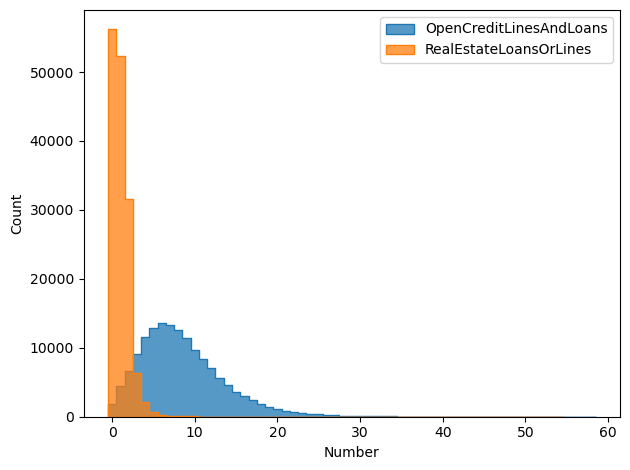

In [608]:
sns.histplot(data=train,   x='NumberOfOpenCreditLinesAndLoans', element='step', discrete=True, label='OpenCreditLinesAndLoans');
ax = sns.histplot(data=train, x='NumberRealEstateLoansOrLines', element='step', discrete=True, label='RealEstateLoansOrLines');
ax.set_xlabel('Number')
plt.legend()

plt.tight_layout()

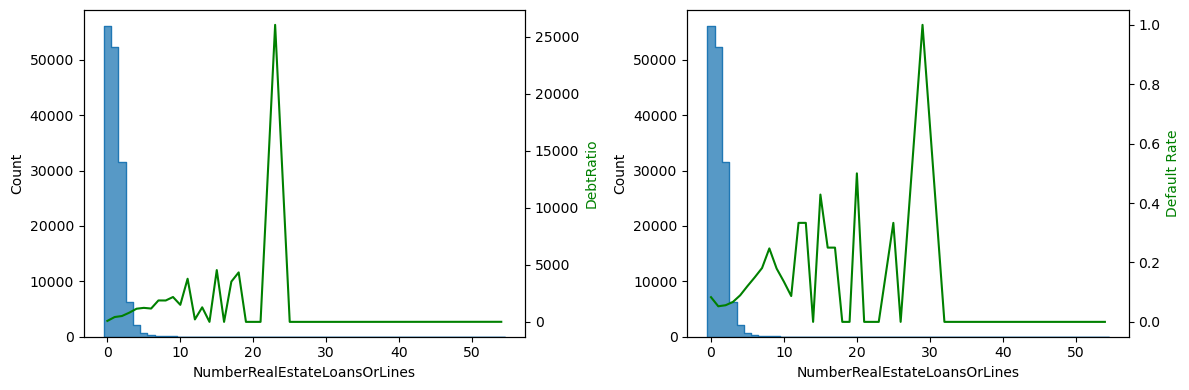

In [652]:
default_rate = train.groupby('NumberRealEstateLoansOrLines').SeriousDlqin2yrs.mean()
debt_ratio   = train.groupby('NumberRealEstateLoansOrLines').DebtRatio.mean()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=train, x='NumberRealEstateLoansOrLines', element='step', discrete=True, ax=axs[0]);
ax2 = axs[0].twinx()
sns.lineplot(data=debt_ratio, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')

sns.histplot(data=train, x='NumberRealEstateLoansOrLines', element='step', discrete=True, ax=axs[1]);
ax2 = axs[1].twinx()
sns.lineplot(data=default_rate, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')
ax2.set_ylabel('Default Rate')

plt.tight_layout()

In [653]:
counts = train.groupby('NumberRealEstateLoansOrLines').size()

stats = pd.concat([counts, default_rate, debt_ratio], axis=1)
stats.columns = ['Count', 'DefaultRate', 'AvgDebtRatio']
stats

,Count,DefaultRate,AvgDebtRatio
NumberRealEstateLoansOrLines,,,
0,56188,0.083149,85.652414
1,52338,0.052505,424.164033
2,31522,0.055993,514.044291
3,6300,0.066984,805.115425
4,2170,0.089401,1153.162134
5,689,0.120464,1229.723482
6,320,0.150000,1169.786602
7,171,0.181287,1880.300392
8,93,0.247312,1876.135471


In [656]:
stats.reset_index().iloc[:5].corr()

,NumberRealEstateLoansOrLines,Count,DefaultRate,AvgDebtRatio
NumberRealEstateLoansOrLines,1.000000,-0.970022,0.262086,0.986195
Count,-0.970022,1.000000,-0.328271,-0.932566
DefaultRate,0.262086,-0.328271,1.000000,0.290239
AvgDebtRatio,0.986195,-0.932566,0.290239,1.000000


In [615]:
train.NumberRealEstateLoansOrLines.quantile(0.99)

4.0

In [628]:
100 * train.NumberRealEstateLoansOrLines.le(4).mean()

99.012

## NumberOfTime30-59DaysPastDueNotWorse

In [630]:
train['NumberOfTime30-59DaysPastDueNotWorse'].describe()

count    150000.000000
mean          0.421033
std           4.192781
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

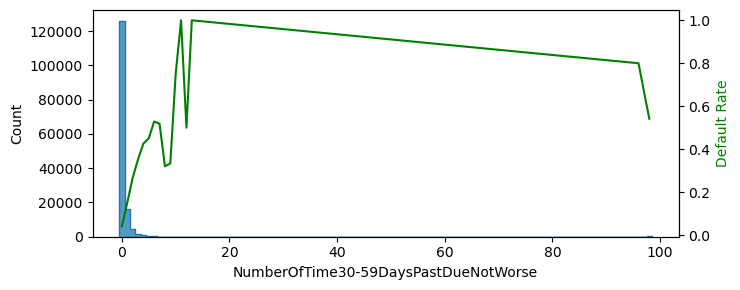

In [690]:
default_rate = train.groupby('NumberOfTime30-59DaysPastDueNotWorse').SeriousDlqin2yrs.mean()

fig, ax1 = plt.subplots(figsize=(7.5,3))

sns.histplot(data=train, x='NumberOfTime30-59DaysPastDueNotWorse', element='step', discrete=True, ax=ax1);
ax2 = ax1.twinx()
sns.lineplot(data=default_rate, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')
ax2.set_ylabel('Default Rate')

plt.tight_layout()

In [666]:
counts = train.groupby('NumberOfTime30-59DaysPastDueNotWorse').size()

stats = pd.concat([counts, default_rate], axis=1)
stats.columns = ['Count', 'DefaultRate']
stats

,Count,DefaultRate
NumberOfTime30-59DaysPastDueNotWorse,,
0,126018,0.040002
1,16033,0.150253
2,4598,0.265115
3,1754,0.352338
4,747,0.425703
5,342,0.450292
6,140,0.528571
7,54,0.518519
8,25,0.320000


Монотонность `DefaultRate` ломается при `NumberOfTime30-59DaysPastDueNotWorse` = 7

In [667]:
train['NumberOfTime30-59DaysPastDueNotWorse'].quantile(0.995)

5.0

In [669]:
train['NumberOfTime30-59DaysPastDueNotWorse'].lt(8).mean()

0.9979066666666667

In [668]:
stats.reset_index().iloc[:8].corr()

,NumberOfTime30-59DaysPastDueNotWorse,Count,DefaultRate
NumberOfTime30-59DaysPastDueNotWorse,1.000000,-0.650748,0.968459
Count,-0.650748,1.000000,-0.762808
DefaultRate,0.968459,-0.762808,1.000000


## NumberOfTime60-89DaysPastDueNotWorse

In [670]:
train['NumberOfTime60-89DaysPastDueNotWorse'].describe()

count    150000.000000
mean          0.240387
std           4.155179
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: float64

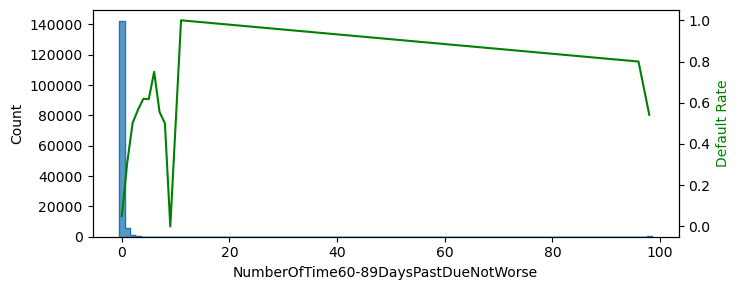

In [691]:
default_rate = train.groupby('NumberOfTime60-89DaysPastDueNotWorse').SeriousDlqin2yrs.mean()

fig, ax1 = plt.subplots(figsize=(7.5,3))

sns.histplot(data=train, x='NumberOfTime60-89DaysPastDueNotWorse', element='step', discrete=True, ax=ax1);
ax2 = ax1.twinx()
sns.lineplot(data=default_rate, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')
ax2.set_ylabel('Default Rate')

plt.tight_layout()

In [674]:
counts = train.groupby('NumberOfTime60-89DaysPastDueNotWorse').size()
default_rate = train.groupby('NumberOfTime60-89DaysPastDueNotWorse').SeriousDlqin2yrs.mean()

stats = pd.concat([counts, default_rate], axis=1)
stats.columns = ['Count', 'DefaultRate']
stats

,Count,DefaultRate
NumberOfTime60-89DaysPastDueNotWorse,,
0,142396,0.050956
1,5731,0.310068
2,1118,0.501789
3,318,0.566038
4,105,0.619048
5,34,0.617647
6,16,0.750000
7,9,0.555556
8,2,0.500000


In [675]:
stats.reset_index().iloc[:7].corr()

,NumberOfTime60-89DaysPastDueNotWorse,Count,DefaultRate
NumberOfTime60-89DaysPastDueNotWorse,1.000000,-0.635066,0.928643
Count,-0.635066,1.000000,-0.838856
DefaultRate,0.928643,-0.838856,1.000000


In [677]:
train['NumberOfTime30-59DaysPastDueNotWorse'].lt(7).mean()

0.9975466666666667

## NumberOfTimes90DaysLate

In [678]:
train.NumberOfTimes90DaysLate.describe()

count    150000.000000
mean          0.265973
std           4.169304
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTimes90DaysLate, dtype: float64

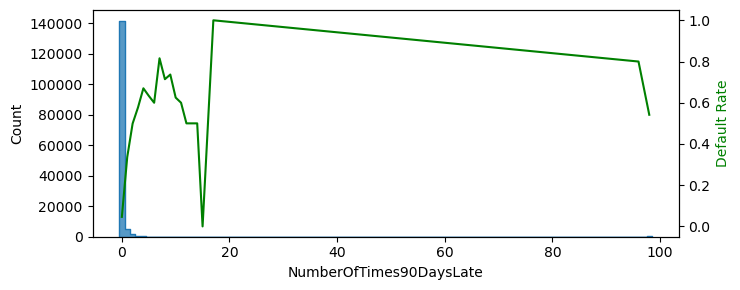

In [692]:
default_rate = train.groupby('NumberOfTimes90DaysLate').SeriousDlqin2yrs.mean()

fig, ax1 = plt.subplots(figsize=(7.5,3))

sns.histplot(data=train, x='NumberOfTimes90DaysLate', element='step', discrete=True, ax=ax1);
ax2 = ax1.twinx()
sns.lineplot(data=default_rate, color='green', ax=ax2);
ax2.yaxis.label.set_color('green')
ax2.set_ylabel('Default Rate')

plt.tight_layout()

In [694]:
counts = train.groupby('NumberOfTimes90DaysLate').size()
default_rate = train.groupby('NumberOfTimes90DaysLate').SeriousDlqin2yrs.mean()

stats = pd.concat([counts, default_rate], axis=1)
stats.columns = ['Count', 'DefaultRate']
stats

,Count,DefaultRate
NumberOfTimes90DaysLate,,
0,141662,0.046265
1,5243,0.336639
2,1555,0.499035
3,667,0.577211
4,291,0.670103
5,131,0.633588
6,80,0.600000
7,38,0.815789
8,21,0.714286


In [699]:
stats.reset_index().iloc[:8].corr()

,NumberOfTimes90DaysLate,Count,DefaultRate
NumberOfTimes90DaysLate,1.000000,-0.599404,0.888319
Count,-0.599404,1.000000,-0.830901
DefaultRate,0.888319,-0.830901,1.000000


In [700]:
train['NumberOfTimes90DaysLate'].lt(8).mean()

0.99778

## Выводы

Дефолт наблюдается у ~6.68% клиентов;

Имеются пропуски в `MonthlyIncome` и `NumberOfDependents`: 19.82% и 2.62% соответственно;

`RevolvingUtilizationOfUnsecuredLines`:

- возростающий монотонный тренд на отрезке \[0, 2\], риск достигает пика в ~0.45
- на интервале \(2, 100\] тренд ломается и риск падает до ~0.3
- затем риск резко обрывается до ~0.05

`age`:

- Наблюдаем пик риска при возрасте около 100 лет, но он, вероятно, обусловлен малой численностью респондентов и случайным всплеском в данных
- Имеется случай возраста "0 лет"
- Молодые более склонны к дефолту
- В целом распределение возраста выглядит нормально :)

`DebtRatio`:

- Достигает максимального значения в 329664.0 с медианой ~ 0.37
- У 97.96% клиентов с `DebtRatio > 50` (у 17.30% пользователей), а также у всех клиентов с `DebtRatio >= 451` (у 14.01% пользователей) доход == 0 или NaN
- Наибольший риск дефолта у пользователей с `DebtRatio` $\in (1, 2]$, порядка 13%

`MonthlyIncome`:

- 29731 (19.82%) пропусков, достигает максимального значения в 3008750.0 с медианой ~ 5400.0 (Right-skewed)
- Мода `DebtRatio` с `MonthlyIncome.isna()`:  1995.73
- Мода `DebtRatio` с `MonthlyIncome == 0`: 1500.28
- При `DebtRatio` > 10 находится 90.04% пропусков
- Распределение количества пропусков и нулевых значений сильно коррелированы

`NumberOfDependents`:

- 3924 (2.62%) пропусков, медиана = 0, максимум = 20
- у 97.36% клиентов не более 3 иждивенцев
- Клиентов с 7 и более иждивенцами: 0.0011%
- По мере увеличения количества иждивенцев растет и риск дефолта, достигая пика в 15.19% при 6 иждивенцах, а затем при 9 иждевенцах риск спадает до нуля

`NumberOfOpenCreditLinesAndLoans`:

- Среднее значение `DebtRatio` имеет прямую корреляцию с `NumberOfOpenCreditLinesAndLoans` и достигает пика в 749.93 при `NumberOfOpenCreditLinesAndLoans` = 25
- 99.24% респондентов имеют не более 25 `NumberOfOpenCreditLinesAndLoans`
- Средняя вероятность дефолта максимальна при `NumberOfOpenCreditLinesAndLoans` = 0 и составляет 25.64%
- Средняя вероятность дефолта убывает с ростом `NumberOfOpenCreditLinesAndLoans`

`NumberRealEstateLoansOrLines`:

- Медиана 1, максимум 54
- 99.01% респондентов имеют 4 или менее `NumberRealEstateLoansOrLines`
- Имеет корреляцию с `DebtRatio` и `NumberOfOpenCreditLinesAndLoans` (по аналогии с `NumberOfOpenCreditLinesAndLoans`)

`NumberOfTime30-59DaysPastDueNotWorse`:

- Медиана 0, максимум 98, причем нет ни одного значения на интервале $[14, 95] \cup \{97\}$. Числа 96 и 98 могут быть какими-то банковскими кодами
- Имеет прямую корреляцию со средним риском дефолта, который достигает пика в 51.85% при `NumberOfTime30-59DaysPastDueNotWorse` = 7
- 99.79% респондентов просрочили платежи 7 или менее раз

`NumberOfTime60-89DaysPastDueNotWorse`:

- Медиана 0, максимум 98, причем нет ни одного значения на интервале $[12, 95] \cup \{97\}$
- Имеет прямую корреляцию со средним риском дефолта, который достигает пика в 75.00% при `NumberOfTime30-59DaysPastDueNotWorse` = 6
- 99.75% респондентов просрочили платежи 6 или менее раз

`NumberOfTimes90DaysLate`:

- Медиана 0, максимум 98, причем нет ни одного значения на интервале $[18, 95] \cup \{97\}$
- Имеет прямую корреляцию со средним риском дефолта, который достигает пика в 81.58% при `NumberOfTime30-59DaysPastDueNotWorse` = 7
- 99.78% респондентов просрочили платежи 7 или менее раз